In [53]:
import pandas as pd
import os

In [54]:
df_fao = pd.read_csv("FAOSTAT_data_en_11-5-2025.csv")
df_fao.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2015,kg/ha,738.7
1,Crops and livestock products,Bulgaria,Production,"Almonds, in shell",2015,t,424.0
2,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2016,kg/ha,852.1
3,Crops and livestock products,Bulgaria,Production,"Almonds, in shell",2016,t,841.0
4,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2017,kg/ha,755.3


In [55]:
fao_cw_df = pd.read_csv("fao_crop_categories.csv")
fao_cw_df.head()

,fao_crop,aggregate_fao_crop,cat_1,``$CAT-AGRICULTURE$``,super_cat
0,"Abaca, manila hemp, raw",0,fibers,fibers,fibers
1,Agave fibres nes,0,fibers,fibers,fibers
2,"Agave fibres, raw, n.e.c.",0,fibers,fibers,fibers
3,"Almonds, in shell",0,nuts,nuts,woody_perennial
4,"Almonds, with shell",0,nuts,nuts,woody_perennial


In [56]:
fao_cw_df = fao_cw_df.rename(columns={"``$CAT-AGRICULTURE$``": "ssp_crop"})
fao_cw_df = fao_cw_df[["fao_crop", "ssp_crop"]]

In [57]:
fao_cw_df.head()

,fao_crop,ssp_crop
0,"Abaca, manila hemp, raw",fibers
1,Agave fibres nes,fibers
2,"Agave fibres, raw, n.e.c.",fibers
3,"Almonds, in shell",nuts
4,"Almonds, with shell",nuts


In [58]:
raw_input_df = pd.read_csv("sisepuede_raw_inputs_latest_BGR_oct_29.csv")
raw_input_df.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_gas_ccs,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3
0,2015,0.0,0.0,0.000669,0.0,2.653341e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR
1,2016,0.0,0.0,0.000696,0.0,2.672084e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR
2,2017,0.0,0.0,0.000307,0.0,1.171112e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR
3,2018,0.0,0.0,0.000398,0.0,1.287155e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR
4,2019,0.0,0.0,0.000389,0.0,1.188816e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR


In [59]:
# Merge df with cw to attach ssp_crop classification
merged = df_fao.merge(fao_cw_df, how="left", left_on="Item", right_on="fao_crop")
merged.head()


,Domain,Area,Element,Item,Year,Unit,Value,fao_crop,ssp_crop
0,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2015,kg/ha,738.7,"Almonds, in shell",nuts
1,Crops and livestock products,Bulgaria,Production,"Almonds, in shell",2015,t,424.0,"Almonds, in shell",nuts
2,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2016,kg/ha,852.1,"Almonds, in shell",nuts
3,Crops and livestock products,Bulgaria,Production,"Almonds, in shell",2016,t,841.0,"Almonds, in shell",nuts
4,Crops and livestock products,Bulgaria,Yield,"Almonds, in shell",2017,kg/ha,755.3,"Almonds, in shell",nuts


In [60]:
# Filter only "fibers"
yield_fibers_df = merged[(merged["ssp_crop"] == "fibers") & (merged["Element"] == "Yield")]
prod_fibers_df = merged[(merged["ssp_crop"] == "fibers") & (merged["Element"] == "Production")]

# aggregate by year and sum values
yield_fibers_df = yield_fibers_df.groupby("Year").agg({"Value": "sum"}).reset_index()
yield_fibers_df

,Year,Value
0,2015,717.6
1,2016,946.8
2,2017,912.2
3,2018,755.5
4,2019,2360.7
5,2020,3468.0
6,2021,1621.1


In [61]:
yield_fibers_df.loc[:, "Value_t_per_ha"] = yield_fibers_df["Value"] / 1000

<Axes: title={'center': 'Fiber Yield over Time (t/ha)'}, xlabel='Year'>

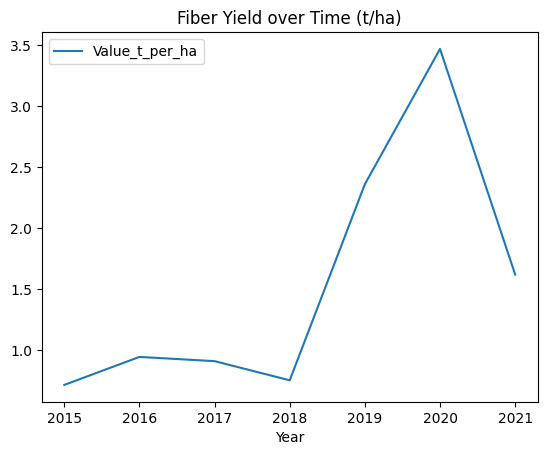

In [62]:
yield_fibers_df.plot(x="Year", y="Value_t_per_ha", kind="line", title="Fiber Yield over Time (t/ha)")

In [63]:
# aggregate production by year and sum values
prod_fibers_df = prod_fibers_df.groupby("Year").agg({"Value": "sum"}).reset_index()
prod_fibers_df

,Year,Value
0,2015,1558.0
1,2016,4251.0
2,2017,4383.0
3,2018,2385.0
4,2019,4579.0
5,2020,4153.0
6,2021,1622.0
7,2022,0.0


<Axes: title={'center': 'Fiber Production over Time (tonnes)'}, xlabel='Year'>

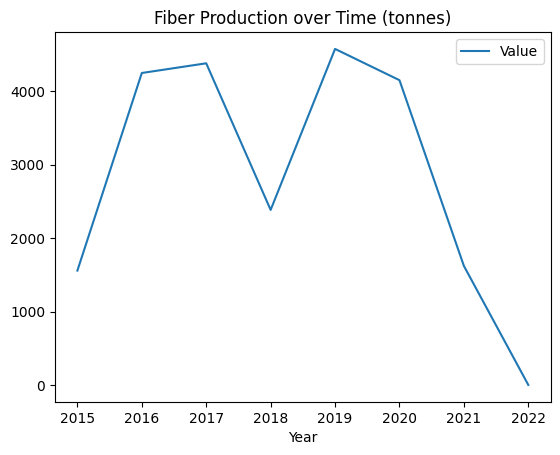

In [65]:
prod_fibers_df.plot(x="Year", y="Value", kind="line", title="Fiber Production over Time (tonnes)")

In [48]:
yield_factors_vars = [col for col in raw_input_df.columns if "yf_agrc" in col]
yield_factors_vars

['yf_agrc_bevs_and_spices_tonne_ha',
 'yf_agrc_cereals_tonne_ha',
 'yf_agrc_fibers_tonne_ha',
 'yf_agrc_fruits_tonne_ha',
 'yf_agrc_herbs_and_other_perennial_crops_tonne_ha',
 'yf_agrc_nuts_tonne_ha',
 'yf_agrc_other_annual_tonne_ha',
 'yf_agrc_other_woody_perennial_tonne_ha',
 'yf_agrc_pulses_tonne_ha',
 'yf_agrc_rice_tonne_ha',
 'yf_agrc_sugar_cane_tonne_ha',
 'yf_agrc_tubers_tonne_ha',
 'yf_agrc_vegetables_and_vines_tonne_ha']

<Axes: title={'center': 'Yield Factor for Fibers over Time (t/ha)'}>

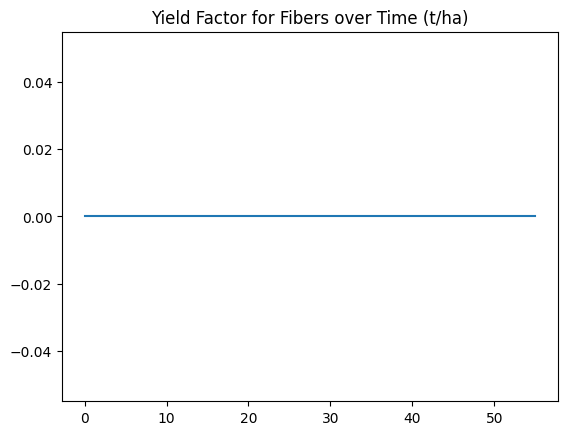

In [51]:
raw_input_df["yf_agrc_fibers_tonne_ha"].plot(kind="line", title="Yield Factor for Fibers over Time (t/ha)")

### Check on vines and vegetables

<Axes: title={'center': 'Vegetables and Vines Yield over Time (t/ha)'}, xlabel='Year'>

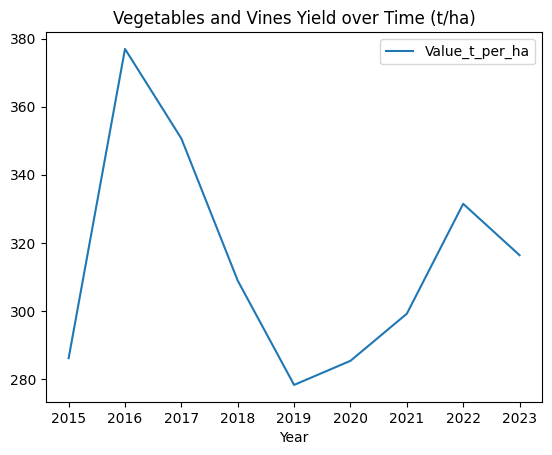

In [67]:
# Filter only "vegetables_and_vines"
yield_vnv_df = merged[(merged["ssp_crop"] == "vegetables_and_vines") & (merged["Element"] == "Yield")]
prod_vnv_df = merged[(merged["ssp_crop"] == "vegetables_and_vines") & (merged["Element"] == "Production")]

# aggregate by year and sum values
yield_vnv_df = yield_vnv_df.groupby("Year").agg({"Value": "sum"}).reset_index()
yield_vnv_df.loc[:, "Value_t_per_ha"] = yield_vnv_df["Value"] / 1000

yield_vnv_df.plot(x="Year", y="Value_t_per_ha", kind="line", title="Vegetables and Vines Yield over Time (t/ha)")

<Axes: title={'center': 'Vegetables and Vines Production over Time (tonnes)'}, xlabel='Year'>

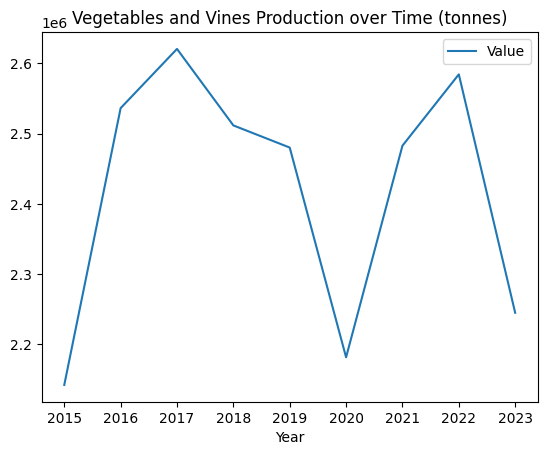

In [68]:
prod_vnv_df = prod_vnv_df.groupby("Year").agg({"Value": "sum"}).reset_index()
prod_vnv_df.plot(x="Year", y="Value", kind="line", title="Vegetables and Vines Production over Time (tonnes)")

<Axes: title={'center': 'Yield Factor for Fibers over Time (t/ha)'}>

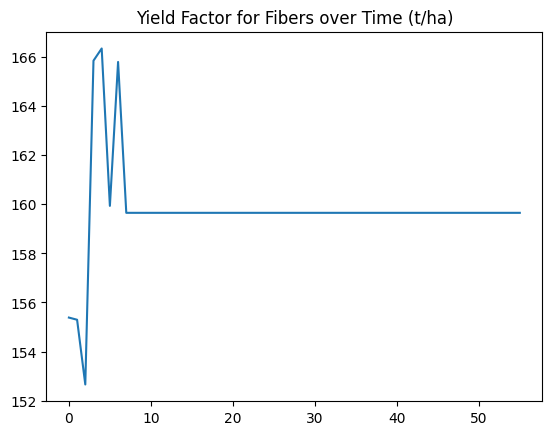

In [69]:
raw_input_df["yf_agrc_vegetables_and_vines_tonne_ha"].plot(kind="line", title="Yield Factor for Fibers over Time (t/ha)")